In [155]:
import sys
import importlib
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

sys.path.append(str(Path().resolve().parent))   # repo root

import scripts.follow_the_mouse as ftm
importlib.reload(ftm)

from scripts.follow_the_mouse import (
    PlexiLine, ROI,
    build_preference_map,
    visualise_preference_map,
    load_object_positions,
    select_camera_per_frame,
    render_composite_video,
    save_rois, load_rois, 
    get_camera_fps,
)


# Build a video that follows the labelled instance

### Metadata

In [140]:
DATA_PATH = Path("/Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/processed/")
HOMOGRAPHY_PATH = DATA_PATH / "homographies/homographies_CameraTop_to_sides_thresh10px.npz"
SLEAP_TOP_PATH  = Path("/Volumes/aeon/aeon/data/raw/AEON3/abcEphysPilot01/2026-04-14T141851Z_calibrateBeforeAprilExperiments/CameraTop/CameraTop_2026-04-14T14-00-00.avi")
VIDEO_ROOT      = Path("/Volumes/aeon/aeon/data/raw")
OUT_DIR         = Path("/Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/videos/")
OUT_DIR.mkdir(parents=True, exist_ok=True)

ARENA      = "AEON3"
EXPERIMENT = "abcEphysPilot01"
SESSION    = "2026-04-14T141851Z_calibrateBeforeAprilExperiments"
CHUNK      = "2026-04-14T14-00-00"

SIDE_CAMERAS = ["CameraEast", "CameraNorth", "CameraSouth", "CameraWest"]
TOP_CAMERA   = "CameraTop"
NEST_CAMERA  = "CameraNest"

ROI_JSON_PATH = OUT_DIR / "rois.json"

In [141]:
def _read_frame_0(root, arena, experiment, session, chunk, camera):
    path = root / arena / experiment / session / camera / f"{camera}_{chunk}.avi"
    cap = cv2.VideoCapture(str(path))
    ok, frame = cap.read()
    T = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    cap.release()
    return frame, T, w, h

top_frame, T, top_w, top_h = _read_frame_0(
    VIDEO_ROOT, ARENA, EXPERIMENT, SESSION, CHUNK, TOP_CAMERA
)
print(f"Top frame: {top_w}×{top_h}  T={T} frames")

# Get dimensions for each side camera
cam_wh = {}
for cam in SIDE_CAMERAS + [NEST_CAMERA]:
    _, _, w, h = _read_frame_0(VIDEO_ROOT, ARENA, EXPERIMENT, SESSION, CHUNK, cam)
    cam_wh[cam] = (w, h)
    print(f"  {cam}: {w}×{h}")

Top frame: 1440×1080  T=29584 frames
  CameraEast: 1440×1080
  CameraNorth: 1440×1080
  CameraSouth: 1440×1080
  CameraWest: 1440×1080
  CameraNest: 720×540


### They differ!

In [142]:
all_cameras = SIDE_CAMERAS + [NEST_CAMERA] + \
              [f"CameraPatch{i}" for i in range(1, 7)]

CAMERA_FPS = get_camera_fps(
    cameras=all_cameras,
    video_root=VIDEO_ROOT,
    arena=ARENA,
    experiment=EXPERIMENT,
    session=SESSION,
    chunk=CHUNK,
)

Reading camera fps from file headers:
  CameraEast            fps=50.0  1440x1080  T=29584  (591.7s)
  CameraNorth           fps=50.0  1440x1080  T=29584  (591.7s)
  CameraSouth           fps=50.0  1440x1080  T=29584  (591.7s)
  CameraWest            fps=50.0  1440x1080  T=29584  (591.7s)
  CameraNest            fps=50.0  720x540  T=29584  (591.7s)
  CameraPatch1          fps=100.0  720x540  T=59166  (591.7s)
  CameraPatch2          fps=100.0  720x540  T=59166  (591.7s)
  CameraPatch3          fps=100.0  720x540  T=59166  (591.7s)
  CameraPatch4          fps=100.0  720x540  T=59166  (591.7s)
  CameraPatch5          fps=100.0  720x540  T=59166  (591.7s)
  CameraPatch6          fps=100.0  720x540  T=59166  (591.7s)


## Define manually the ROIs for the Nest and Patches

In [158]:
rois = [
    # --- Nest ---
    ROI.rect(
        name="Nest",
        camera=NEST_CAMERA,
        center_x=1290.0,   # x centre in Top pixel coords
        center_y=530.0,    # y centre in Top pixel coords
        width_px=110.0,
        height_px=130.0,
        color=(0, 200, 255),  
    ),

    # --- Patches (circles) ---
    ROI.circle("Patch1", "CameraPatch1", cx=705.0,  cy=205.0,  radius=30.0, color=(0, 255, 0)),
    ROI.circle("Patch2", "CameraPatch2", cx=1000.0, cy=370.0,  radius=30.0, color=(0, 255, 0)),
    ROI.circle("Patch3", "CameraPatch3", cx=1010.0, cy=710.0,  radius=30.0, color=(0, 255, 0)),
    ROI.circle("Patch4", "CameraPatch4", cx=720.0,  cy=885.0,  radius=30.0, color=(0, 255, 0)),
    ROI.circle("Patch5", "CameraPatch5", cx=425.0,  cy=720.0,  radius=30.0, color=(0, 255, 0)),
    ROI.circle("Patch6", "CameraPatch6", cx=415.0,  cy=380.0,  radius=30.0, color=(0, 255, 0)),
]

save_rois(rois, ROI_JSON_PATH)

# Quick check: print each ROI's derived corners
for r in rois:
    if r.center_x is not None:
        print(f"{r.name}: centre=({r.center_x}, {r.center_y})  "
              f"→ corners ({r.x0:.0f},{r.y0:.0f}) to ({r.x1:.0f},{r.y1:.0f})")
    else:
        print(f"{r.name}: centre=({r.cx}, {r.cy})  radius={r.radius}")


Saved 7 ROIs → /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/videos/rois.json
Nest: centre=(1290.0, 530.0)  → corners (1235,465) to (1345,595)
Patch1: centre=(705.0, 205.0)  radius=30.0
Patch2: centre=(1000.0, 370.0)  radius=30.0
Patch3: centre=(1010.0, 710.0)  radius=30.0
Patch4: centre=(720.0, 885.0)  radius=30.0
Patch5: centre=(425.0, 720.0)  radius=30.0
Patch6: centre=(415.0, 380.0)  radius=30.0


### Define Plexiglass line

In [159]:
plexi_line = PlexiLine(
    p1=(400, 0),               # top of the line (adjust to your arena)
    p2=(1060, 1100),           # bottom of the line
    left_cameras=["CameraEast", "CameraSouth"],
    right_cameras=["CameraWest", "CameraNorth"],
)

# Set to None to disable:
# plexi_line = None


## Build a 'which camera is best' map on top of CameraTop view

In [160]:
best_cam_idx, xs, ys = build_preference_map(
    homography_path=HOMOGRAPHY_PATH,
    top_frame=top_frame,
    side_cameras=SIDE_CAMERAS,
    plexi_line=plexi_line,
    grid_step_px=10,
    cam_wh=cam_wh,
)


Preference map built: 108×144 grid over 1440×1080 px


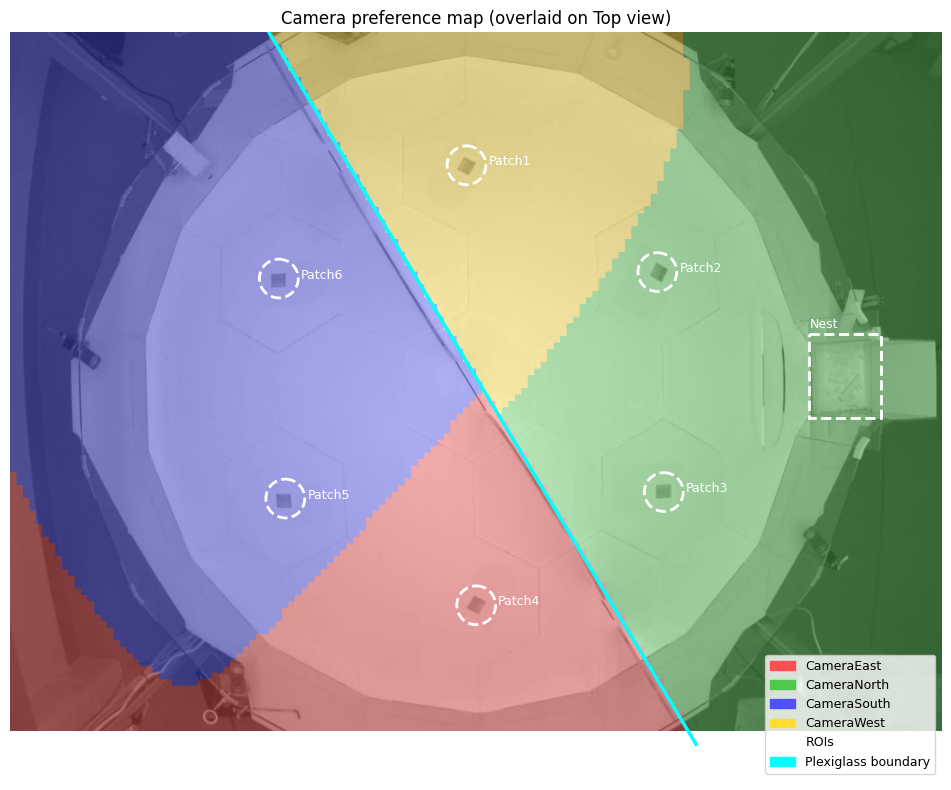

In [161]:
visualise_preference_map(
    best_cam_idx=best_cam_idx,
    xs=xs,
    ys=ys,
    top_frame=top_frame,
    side_cameras=SIDE_CAMERAS,
    rois=rois,
    plexi_line=plexi_line,
)


## Identify instance centre from labels (from xarray) and show on Top view

  NC: 15761 raw valid → 21693 after interpolation (T=29584)


/Users/zosiasus/Documents/Aeon3_SLEAP/AEON_sleap_analysis/scripts/follow_the_mouse.py:416: RuntimeWarning: All-NaN slice encountered
  annotate: If True, draw camera name and frame index on output.


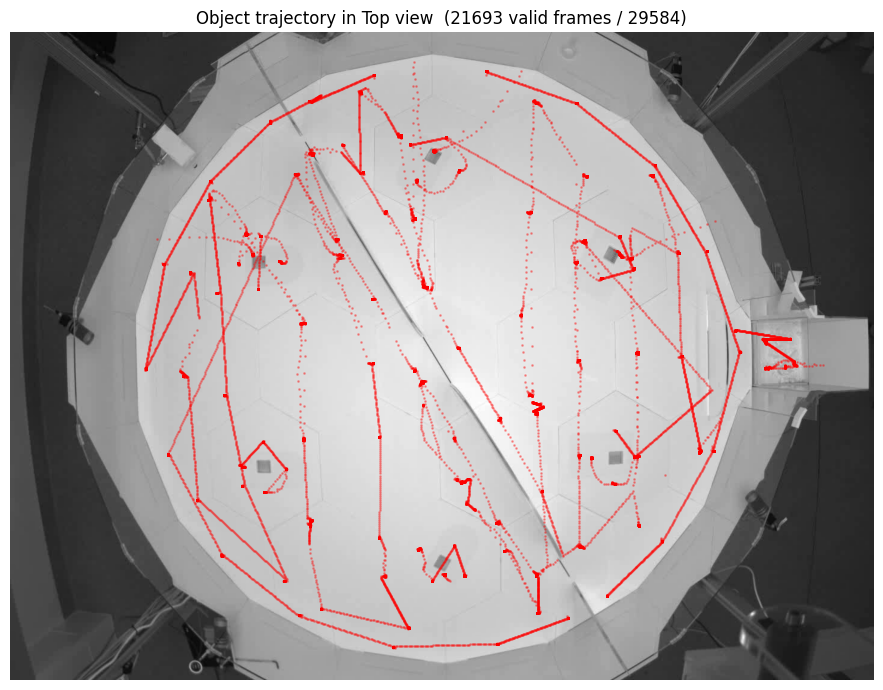

In [162]:
centers_top, centers_valid = load_object_positions(
    nc_path=DATA_PATH / "CameraTop_pose_data.nc",
    T=T,
    conf_threshold=0.3,
    interp_window=150,
)

# Quick sanity plot: object trajectory on Top frame
top_rgb = cv2.cvtColor(top_frame, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(top_rgb)
valid_pts = centers_top[centers_valid]
ax.scatter(valid_pts[:, 0], valid_pts[:, 1], s=1, c="red", alpha=0.3)
ax.set_title(f"Object trajectory in Top view  ({centers_valid.sum()} valid frames / {T})")
ax.axis("off")
plt.tight_layout()
plt.show()


## Select best camera (from side cameras) for each frame

Camera selection counts:
  CameraEast                  5754 frames  (19.4%)
  CameraNorth                 9811 frames  (33.2%)
  CameraSouth                 9356 frames  (31.6%)
  CameraWest                  4663 frames  (15.8%)


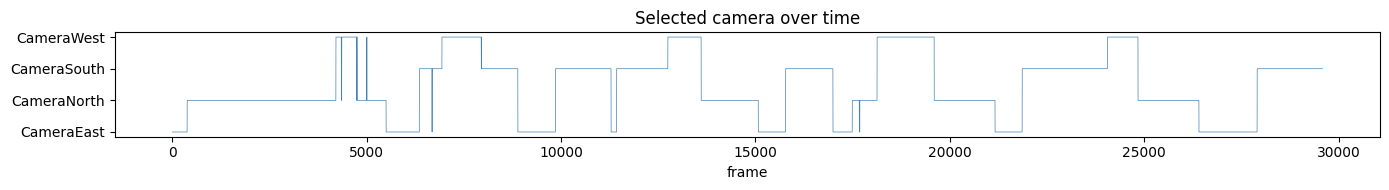

In [163]:
selected_cam = select_camera_per_frame(
    centers_top=centers_top,
    centers_valid=centers_valid,
    best_cam_idx=best_cam_idx,
    xs=xs,
    ys=ys,
    side_cameras=SIDE_CAMERAS,
    rois=rois,
    grid_step_px=10,
)

# Summary
from collections import Counter
print("Camera selection counts:")
for cam, count in sorted(Counter(selected_cam).items()):
    print(f"  {cam:25s} {count:6d} frames  ({100*count/T:.1f}%)")

# Plot camera selection over time
cam_list = SIDE_CAMERAS
idx_series = [cam_list.index(c) if c in cam_list else -1 for c in selected_cam]

plt.figure(figsize=(14, 2))
plt.plot(idx_series, lw=0.5, color="steelblue")
plt.yticks(range(len(cam_list)), cam_list)
plt.xlabel("frame")
plt.title("Selected camera over time")
plt.tight_layout()
plt.show()


## Render video

### Short test video

In [164]:
test_out = OUT_DIR / "composite_patch_test.mp4"

render_composite_video(
    output_path=test_out,
    selected_cam=selected_cam,
    centers_top=centers_top,
    centers_valid=centers_valid,
    camera_fps=CAMERA_FPS,
    homography_path=HOMOGRAPHY_PATH,
    video_root=VIDEO_ROOT,
    arena=ARENA,
    experiment=EXPERIMENT,
    session=SESSION,
    chunk=CHUNK,
    side_cameras=SIDE_CAMERAS,
    rois=rois,
    t_start=20000,
    t_end=21000,          
    fps_out=30,
    crop_fraction=0.25,  # crop window = 25% of camera frame around object
    pip_scale=0.28,      # PiP inset = 28% of output width
    annotate=True,
    centre_dot=True,
)


Rendering frames 20000→21000 to composite_patch_test.mp4 ...
  Written 500 / 1001 frames
  Written 1000 / 1001 frames
Done. 1001 frames → /Volumes/homes/live/zsus/aeon_sleap/abcEphysPilot01/videos/composite_patch_test.mp4


### Full composite video

In [165]:
full_out = OUT_DIR / "composite_full.mp4"

render_composite_video(
    output_path=full_out,
    selected_cam=selected_cam,
    centers_top=centers_top,
    centers_valid=centers_valid,
    camera_fps=CAMERA_FPS,
    homography_path=HOMOGRAPHY_PATH,
    video_root=VIDEO_ROOT,
    arena=ARENA,
    experiment=EXPERIMENT,
    session=SESSION,
    chunk=CHUNK,
    side_cameras=SIDE_CAMERAS,
    rois=rois,
    t_start=0,
    t_end=T - 1,
    fps_out=30,
    crop_fraction=0.25,
    pip_scale=0.28,
    annotate=True,
    centre_dot=False,
)


Rendering frames 0→29583 to composite_full.mp4 ...
  Written 500 / 29584 frames
  Written 1000 / 29584 frames
  Written 1500 / 29584 frames
  Written 2000 / 29584 frames
  Written 2500 / 29584 frames
  Written 3000 / 29584 frames
  Written 3500 / 29584 frames
  Written 4000 / 29584 frames
  Written 4500 / 29584 frames
  Written 5000 / 29584 frames
  Written 5500 / 29584 frames
  Written 6000 / 29584 frames
  Written 6500 / 29584 frames
  Written 7000 / 29584 frames
  Written 7500 / 29584 frames
  Written 8000 / 29584 frames
  Written 8500 / 29584 frames
  Written 9000 / 29584 frames
  Written 9500 / 29584 frames
  Written 10000 / 29584 frames
  Written 10500 / 29584 frames
  Written 11000 / 29584 frames
  Written 11500 / 29584 frames
  Written 12000 / 29584 frames
  Written 12500 / 29584 frames
  Written 13000 / 29584 frames
  Written 13500 / 29584 frames
  Written 14000 / 29584 frames
  Written 14500 / 29584 frames
  Written 15000 / 29584 frames
  Written 15500 / 29584 frames
  Writte